---
title: "Catalog — query / intersect / union set algebra"
---

# Catalog set algebra: query / intersect / union

Catalogs support set-algebra operations that return new catalogs —
composable filters and joins over file collections. This notebook
shows the three patterns on real data:

- `query` filters by space + time.
- `intersect` pairs two catalogs by spatial + temporal overlap.
- `union` concatenates two catalogs (with auto-reproject).

Two real catalogs participate:

1. **Imagery** — eight cloud-free Sentinel-2 L2A scenes over Lake
   Tahoe (MGRS 10SGJ, June–July 2024) pulled from MPC.
2. **Labels** — Natural Earth's admin-1 (states/provinces)
   polygons, restricted to **California, Nevada, and Oregon**.
   Plays the role of any vector overlay you might want to pair with
   imagery (CORINE land-cover, GHCN station footprints, MODIS land
   classification, …).

In [1]:
import geocatalog as gc
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import shapely.geometry

from geostack import (
    LAKE_TAHOE_BBOX,
    LAKE_TAHOE_TILE,
    load_natural_earth_admin1,
    load_stac_items,
)

## 1. Build the imagery catalog (eight S2 scenes)

In [2]:
items = load_stac_items(
    "sentinel-2-l2a",
    LAKE_TAHOE_BBOX,
    "2024-06-01/2024-07-31",
    tile=LAKE_TAHOE_TILE,
    max_cloud_cover=15,
)
imagery = gc.build_raster_catalog(
    [it.assets["B04"].href for it in items],
    filename_regex=r".*_(?P<date>\d{8})T\d{6}_.*\.tif",
    target_crs="EPSG:32610",
)
imagery.gdf["mission"] = [
    "S2A" if "S2A" in it.id else "S2B" for it in items
]
print(f"imagery: {len(imagery)} rows  bounds={tuple(round(x, 1) for x in imagery.total_bounds)}")
print(f"missions: {imagery.gdf['mission'].value_counts().to_dict()}")

imagery: 22 rows  bounds=(699960.0, 4290240.0, 809760.0, 4400040.0)
missions: {'S2A': 12, 'S2B': 10}


## 2. Build the labels catalog (admin-1 polygons)

Natural Earth admin-1 polygons restricted to the three states whose
admin boundary intersects the Lake Tahoe MGRS tile. We hand the
`geopandas` GeoDataFrame to `InMemoryGeoCatalog` directly with the
`vector` backend so the catalog set-algebra story works against a
vector overlay just like it would against another raster archive.

In [3]:
ne_admin1 = load_natural_earth_admin1()
target_states = ["California", "Nevada", "Oregon"]
admin_subset = ne_admin1[ne_admin1["name"].isin(target_states)].copy()
admin_subset["filepath"] = [f"admin_{s.lower()}.gpkg" for s in admin_subset["name"]]
admin_subset["start_time"] = pd.Timestamp("2024-01-01")
admin_subset["end_time"] = pd.Timestamp("2024-12-31")
admin_subset = admin_subset[
    ["filepath", "geometry", "start_time", "end_time", "name"]
]
labels = gc.InMemoryGeoCatalog(
    gpd.GeoDataFrame(admin_subset, geometry="geometry", crs="EPSG:4326"),
    backend="vector",
)
print(f"labels: {len(labels)} admin-1 rows ({', '.join(target_states)})")

labels: 3 admin-1 rows (California, Nevada, Oregon)


## 3. Plot the two catalogs together

Imagery footprints are 110 × 110 km tiles in UTM 10N; the labels
are state-sized polygons in EPSG:4326. We reproject the imagery to
4326 for the overlay so both fit in one map.

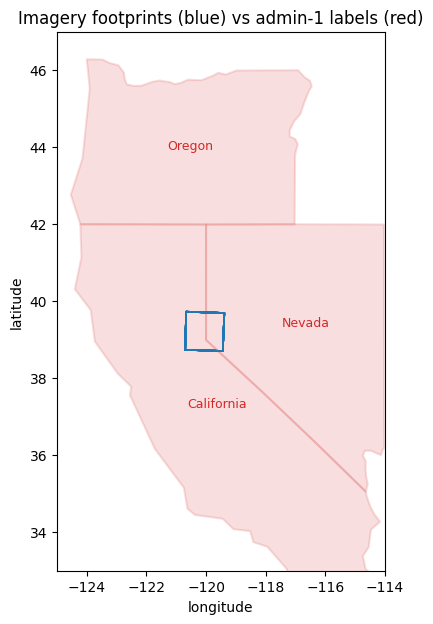

In [4]:
imagery_4326 = imagery.gdf.to_crs("EPSG:4326")
fig, ax = plt.subplots(figsize=(8, 7))
labels.gdf.plot(ax=ax, edgecolor="C3", facecolor="C3", alpha=0.15, linewidth=1.5)
for _, row in labels.gdf.iterrows():
    cx, cy = row.geometry.centroid.coords[0]
    ax.text(cx, cy, row["name"], fontsize=9, ha="center", color="C3")
imagery_4326.plot(ax=ax, edgecolor="C0", facecolor="none", linewidth=1.2)
ax.set_xlim(-125, -114)
ax.set_ylim(33, 47)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Imagery footprints (blue) vs admin-1 labels (red)")
plt.show()

## 4. `query` — spatial AND temporal filter on imagery

Ask for scenes overlapping the **western shore** of Lake Tahoe in
the first week of June.

In [5]:
hits = imagery.query(
    bounds=(750000, 4318000, 758000, 4332000),
    crs="EPSG:32610",
    time=("2024-06-01", "2024-06-10"),
)
print(f"first-week western-shore hits: {len(hits)}")
print(hits.gdf[["mission", "start_time", "filepath"]].head().to_string())

first-week western-shore hits: 4
                                                  mission start_time                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               filepath
datetime                                                                                                                                                                                                                                                                                                                                                                   

## 5. `intersect` — cross-catalog AND

`intersect(imagery, labels)` returns the rows whose **footprints
AND time intervals** overlap. Each surviving row's geometry is
clipped to the intersection, and the time interval is the per-row
temporal intersection. Since the admin polygons span all of 2024,
every imagery row in the AOI will pair with whichever state
polygon it sits inside.

In [6]:
paired = gc.intersect(imagery, labels, spatial_only=True)
print(f"len(paired): {len(paired)}  (every imagery row that hits CA/NV/OR)")
paired_4326 = paired.gdf.to_crs("EPSG:4326")
print(paired_4326[["filepath", "geometry"]].head().to_string())

len(paired): 44  (every imagery row that hits CA/NV/OR)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                filepath                                                                                                                                geometry
datetime                                                                                                                                                                                                                       

Plot the clipped intersection footprints — they're now state-sliced
imagery tiles.

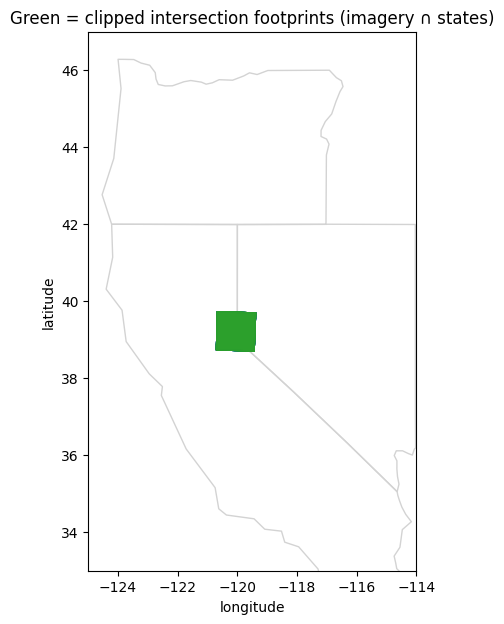

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
labels.gdf.plot(ax=ax, edgecolor="lightgray", facecolor="none", linewidth=1)
imagery_4326.plot(ax=ax, edgecolor="C0", facecolor="none", linewidth=1)
paired_4326.plot(ax=ax, edgecolor="C2", facecolor="C2", alpha=0.4)
ax.set_xlim(-125, -114)
ax.set_ylim(33, 47)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Green = clipped intersection footprints (imagery ∩ states)")
plt.show()

## 6. `union` — cross-catalog OR

Useful when you have multiple sensors (Landsat 7 + Landsat 8, or
Sentinel-2 + Sentinel-3) you want to treat as a single virtual
dataset. We fabricate a tiny "Sentinel-3 OLCI" catalog row at low
resolution that overlaps the same AOI to show the merge.

In [8]:
s3_olci = gc.InMemoryGeoCatalog(
    gpd.GeoDataFrame(
        [
            {
                "filepath": "S3_OLCI_20240615.tif",
                "geometry": shapely.geometry.box(749000, 4316000, 770000, 4340000),
                "start_time": pd.Timestamp("2024-06-15"),
                "end_time": pd.Timestamp("2024-06-15 23:59:59"),
                "mission": "S3A",
            }
        ],
        geometry="geometry",
        crs="EPSG:32610",
    ),
    backend="raster",
)
combined = gc.union(imagery, s3_olci)
print(f"len(combined): {len(combined)}  ({len(imagery)} S2 + {len(s3_olci)} S3)")
print(combined.gdf["mission"].value_counts().to_dict())

len(combined): 23  (22 S2 + 1 S3)
{'S2A': 12, 'S2B': 10, 'S3A': 1}


### Cross-CRS union

`union` silently reprojects the second catalog if its CRS does not
match — `self.crs` always wins.

In [9]:
s3_4326 = gc.InMemoryGeoCatalog(
    gpd.GeoDataFrame(
        [
            {
                "filepath": "S3_OLCI_4326.tif",
                "geometry": shapely.geometry.box(*LAKE_TAHOE_BBOX),
                "start_time": pd.Timestamp("2024-06-15"),
                "end_time": pd.Timestamp("2024-06-15 23:59:59"),
                "mission": "S3A",
            }
        ],
        geometry="geometry",
        crs="EPSG:4326",
    ),
    backend="raster",
)
reprojected = gc.union(imagery, s3_4326)
print(f"len(reprojected): {len(reprojected)}")
print(f"reprojected.gdf.crs: {reprojected.gdf.crs}")
print("⇒ second catalog's footprints reprojected into UTM 10N silently")

len(reprojected): 23
reprojected.gdf.crs: EPSG:32610
⇒ second catalog's footprints reprojected into UTM 10N silently


## 7. `where` — pandas-`.query()` passthrough

Non-geometric filter (mission, cloud %, processing level) — the
pandas escape hatch.

In [10]:
imagery_a = imagery.where("mission == 'S2A'")
print(f"S2A-only: {len(imagery_a)} rows out of {len(imagery)}")

S2A-only: 12 rows out of 22


## Recap

The four operations compose into a small algebra over file
collections:

| Op | Returns | Use it for |
|---|---|---|
| `catalog.query(bounds, crs, time)` | sub-catalog | Spatial+temporal filter (the most common case). |
| `catalog.where("sql_like")` | sub-catalog | Non-geometric filters (mission, cloud %, sensor). |
| `gc.intersect(a, b, spatial_only=...)` | row-aligned pair | Join imagery with labels / co-located sensors. |
| `gc.union(a, b)` | concatenated catalog | Multi-sensor virtual dataset; auto-reproject. |

Combine them freely — `gc.intersect(imagery.query(bbox, time),
labels.where("class == 'forest'"))` is one production-ready pattern.